In [3]:
import pandas as pd

# File load karo
df = pd.read_csv('email_phishing_data.csv')

# Top 5 rows dekho
df.head()

C:\Users\Dell Latitude 7400\AppData\Local\Temp\ipykernel_22044\134872342.py:4: DtypeWarning: Columns (1,3,4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('email_phishing_data.csv')


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140.0,94,52.0,0,ac,0,0,0.0,0
1,5.0,5,1.0,0,0,0,0,0.0,0
2,34.0,32,15.0,0,0,0,0,0.0,0
3,6.0,6,2.0,0,0,0,0,0.0,0
4,9.0,9,2.0,0,0,0,0,0.0,0


In [8]:
# Convert column to numeric, errors='coerce' matlab "ac" ko NaN bana do
df['num_unique_domains'] = pd.to_numeric(df['num_unique_domains'], errors='coerce')

df.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140.0,94,52.0,0,NaN,0,0,0.0,0
1,5.0,5,1.0,0,0.0,0,0,0.0,0
2,34.0,32,15.0,0,0.0,0,0,0.0,0
3,6.0,6,2.0,0,0.0,0,0,0.0,0
4,9.0,9,2.0,0,0.0,0,0,0.0,0


In [10]:
df.fillna(0, inplace=True)
df.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
0,140.0,94,52.0,0,0.0,0,0,0.0,0
1,5.0,5,1.0,0,0.0,0,0,0.0,0
2,34.0,32,15.0,0,0.0,0,0,0.0,0
3,6.0,6,2.0,0,0.0,0,0,0.0,0
4,9.0,9,2.0,0,0.0,0,0,0.0,0


In [4]:
# Shape and basic info
print(df.shape)
print(df.info())

(524846, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   num_words            524845 non-null  float64
 1   num_unique_words     524845 non-null  object 
 2   num_stopwords        524842 non-null  float64
 3   num_links            524841 non-null  object 
 4   num_unique_domains   524840 non-null  object 
 5   num_email_addresses  524844 non-null  object 
 6   num_spelling_errors  524846 non-null  int64  
 7   num_urgent_keywords  524844 non-null  float64
 8   label                524846 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 36.0+ MB
None


In [5]:
# Agar labels hain to unique values dekho
print(df['label'].value_counts())  # Replace 'target' with your label column name

label
0    517897
1      6949
Name: count, dtype: int64


In [11]:
#Missing values check karo:
df.isnull().sum()

num_words              0
num_unique_words       0
num_stopwords          0
num_links              0
num_unique_domains     0
num_email_addresses    0
num_spelling_errors    0
num_urgent_keywords    0
label                  0
dtype: int64

In [12]:
# K-Means mein label (yani label column) use nahi hota. Sirf features chahiyein
X = df.drop('label', axis=1)  # label hata do

In [18]:
X.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,140.0,94,52.0,0,0.0,0,0,0.0
1,5.0,5,1.0,0,0.0,0,0,0.0
2,34.0,32,15.0,0,0.0,0,0,0.0
3,6.0,6,2.0,0,0.0,0,0,0.0
4,9.0,9,2.0,0,0.0,0,0,0.0


In [19]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []  # Within-Cluster Sum of Squares

# 1 to 10 clusters try karo
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot karo
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

ValueError: could not convert string to float: '"85"'

In [20]:
print(X.dtypes)

num_words              float64
num_unique_words        object
num_stopwords          float64
num_links               object
num_unique_domains     float64
num_email_addresses     object
num_spelling_errors      int64
num_urgent_keywords    float64
dtype: object


In [21]:
# Convert all columns to numeric, errors='coerce' means invalid strings will become NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Replace NaN with 0
X.fillna(0, inplace=True)

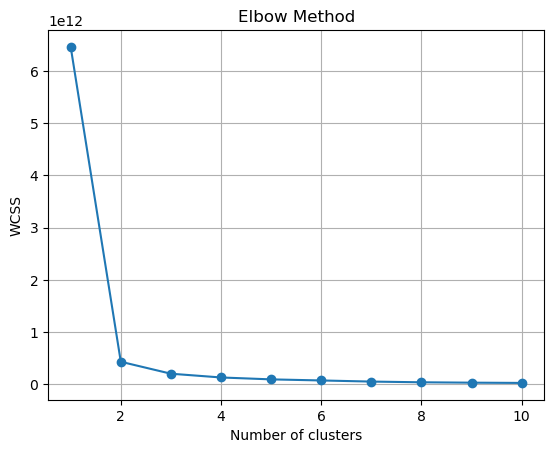

In [23]:
# Elbow Method – Best K (cluster) choose karna
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_) # inertia_ = Within-Cluster Sum of Squares

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [24]:
# Final model with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=0)
df['Cluster'] = kmeans.fit_predict(X)

In [28]:
df.sample(10)

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label,Cluster
79928,164.0,119,32.0,0,0.0,8,24,0.0,0,0
509941,442.0,242,161.0,4,4.0,1,27,0.0,0,0
242008,570.0,295,175.0,0,0.0,0,28,0.0,0,0
145131,16.0,16,9.0,0,0.0,0,0,0.0,0,0
280175,190.0,113,52.0,0.0,0.0,0.0,9,0.0,0,0
8226,117.0,88,31.0,1,1.0,0,14,0.0,0,0
186430,228.0,104,26.0,0,0.0,9,54,0.0,0,0
485328,5874.0,1827,1719.0,0,0.0,0,427,2.0,0,0
117023,15.0,15,0.0,0,0.0,0,1,0.0,0,0
9369,105.0,82,25.0,0,0.0,1,6,0.0,0,0


In [29]:
# Har cluster ka average dekho
print(df.groupby('Cluster').mean())

TypeError: agg function failed [how->mean,dtype->object]

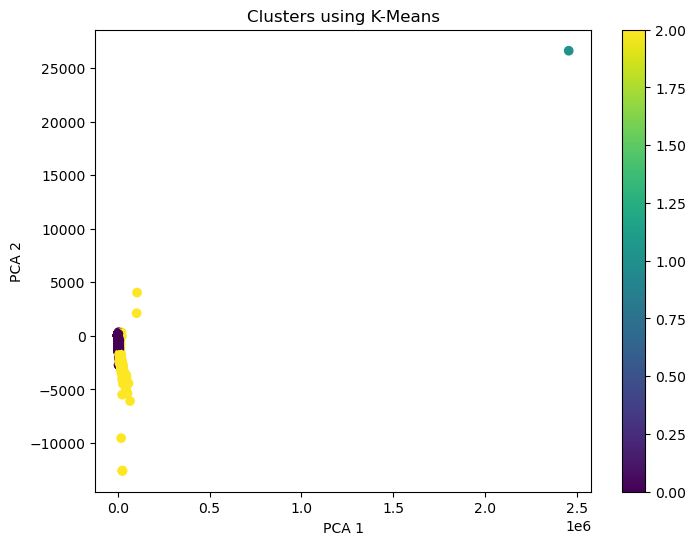

In [30]:
from sklearn.decomposition import PCA # PCA (Principal Component Analysis) ek technique hai jo
                                      # high-dimensional data ko 2 dimensions mein convert karta hai, taake hum usko plot kar saken.

# PCA ka object bana rahe hain jismein sirf 2 components (columns) chahiye visualization ke liye
pca = PCA(n_components=2)

# Apne original features X ko PCA ke zariye 2 dimensions mein convert kar rahe hain
X_pca = pca.fit_transform(X)

# Figure ka size set kar rahe hain
plt.figure(figsize=(8, 6))

# Scatter plot bana rahe hain:
# X_pca[:, 0] → pehla PCA component (x-axis)
# X_pca[:, 1] → doosra PCA component (y-axis)
# c=df['Cluster'] → har point ka color uske cluster ke mutabiq
# cmap='viridis' → color style set kar rahe hain
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Cluster'], cmap='viridis')

# Graph ka title
plt.title('Clusters using K-Means')

# X aur Y axis ke labels
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')

# Color bar show kar rahe hain (batata hai ke kaunsa color kis cluster ko represent karta hai)
plt.colorbar()

# Graph display karo
plt.show()
